In [1]:
import os
import keras
from keras.utils import to_categorical
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
seed = 0
np.random.seed(seed)
import tensorflow as tf
tf.random.set_seed(seed)

2026-05-05 13:24:36.347549: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777980276.376159  839519 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777980276.383303  839519 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-05 13:24:36.408710: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from hgq.utils.sugar import Dataset

X_train_val = np.load('X_train_val.npy')
X_test = np.load('X_test.npy')
y_train_val = np.load('y_train_val.npy')
y_test = np.load('y_test.npy')
classes = np.load('classes.npy', allow_pickle=True)


dataset_train = Dataset(X_train_val, y_train_val, batch_size=33200, device='gpu:0')
dataset_test = Dataset(X_test, y_test, batch_size=33200, device='gpu:0')


I0000 00:00:1777980278.623485  839519 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [3]:
from keras.models import Sequential
from keras.optimizers import Adam
from keras.losses import SparseCategoricalCrossentropy
from hgq.config import QuantizerConfig, QuantizerConfigScope, LayerConfigScope
from hgq.layers import QDense, QSoftmax
from hgq.constraints import MinMax

In [ ]:
"""scope_weights = QuantizerConfigScope(
    place='all', 
    default_q_type='kbi', 
    heterogeneous_axis=None, 
    homogeneous_axis=(),
    overflow_mode='sat_sym'
)

scope_activations = QuantizerConfigScope(
    place='datalane', 
    default_q_type='kif', 
    heterogeneous_axis=None, 
    homogeneous_axis=(0, 1), 
    overflow_mode='wrap'
)"""

In [4]:
iq_conf = QuantizerConfig(place='datalane', k0=1)
with (
    QuantizerConfigScope(place='all', default_q_type='kbi',overflow_mode='SAT_SYM',heterogeneous_axis=None,homogeneous_axis=(),trainable=True),
    QuantizerConfigScope(place='datalane', default_q_type='kif', overflow_mode='WRAP', f0=8, i0=4, k0=0, fc=MinMax(2, 10), ic=MinMax(2, 6), heterogeneous_axis=(), homogeneous_axis=None, trainable=True),
    LayerConfigScope(enable_ebops=True, beta0=1e-6),
   ):

        
    inputs = keras.layers.Input(shape=(16,), name='input_layer')
    x = QDense(64, activation='relu', iq_conf=iq_conf, name='dense_0')(inputs)
    x = QDense(32, activation='relu', name='dense_1')(x)
    x = QDense(32, activation='relu', name='dense_2')(x)
    outputs = QDense(5, name='dense_3')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    
loss = keras.losses.CategoricalCrossentropy(from_logits=True)
opt = keras.optimizers.Adam()

model.compile(opt, loss, metrics=['accuracy'], jit_compile=True, steps_per_execution=32)

In [5]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_0 (QDense)                │ (None, 64)             │         4,403 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (QDense)                │ (None, 32)             │         8,326 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (QDense)                │ (None, 32)             │         4,230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (QDense)                │ (None, 5)              │           666 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,625 (55.93 KB)

 Trainable params: 13,186 (51.51 KB)

 Non-trainable params: 4,439 (4.43 KB)

In [6]:
import keras
import numpy as np
from math import cos, pi
from hgq.utils.sugar import BetaScheduler, Dataset, FreeEBOPs, ParetoFront, PBar, PieceWiseSchedule, EarlyStoppingWithEbopsThres
from keras.callbacks import CSVLogger, LearningRateScheduler

OUTPUT_PATH = '/home/slopin/hls4ml_proj/model_HGQ/model_outputs'

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)
    print(f"Created new folder: {OUTPUT_PATH}")

def cosine_decay_restarts_schedule(
    initial_learning_rate: float, first_decay_steps: int, t_mul=1.0, m_mul=1.0, alpha=0.0, alpha_steps=0
):
    def schedule(global_step):
        n_cycle = 1
        cycle_step = global_step
        cycle_len = first_decay_steps
        while cycle_step >= cycle_len:
            cycle_step -= cycle_len
            cycle_len *= t_mul
            n_cycle += 1

        cycle_t = min(cycle_step / (cycle_len - alpha_steps), 1)
        lr = alpha + 0.5 * (initial_learning_rate - alpha) * (1 + cos(pi * cycle_t)) * m_mul ** max(n_cycle - 1, 0)
        return lr

    return schedule

pbar = PBar(
        'loss: {loss:.2f}/{val_loss:.2f} - acc: {accuracy:.4f}/{val_accuracy:.4f} - lr: {learning_rate:.2e} - beta: {beta:.1e}'
    )
ebops = FreeEBOPs()
pareto = ParetoFront(
        OUTPUT_PATH,
        ['val_accuracy', 'ebops'],
        [1, -1],
        fname_format='epoch={epoch}-val_acc={val_accuracy:.3f}-ebops={ebops}-val_loss={val_loss:.3f}.keras',
    )

beta_sched = BetaScheduler(PieceWiseSchedule([(0, 1e-6, 'constant'), (500, 1e-6, 'log'), (30000, 1e-3, 'constant')]))
lr_sched = LearningRateScheduler(
        cosine_decay_restarts_schedule(5e-3, 4000, t_mul=1.0, m_mul=0.94, alpha=1e-6, alpha_steps=50)
    )

csv_logger = CSVLogger('/home/slopin/hls4ml_proj/model_HGQ/JET_HGQ_Training_log.csv', append=True, separator=';')

callbacks = [ebops, lr_sched, beta_sched, pbar, pareto, csv_logger,]

In [7]:
from tensorflow.python.client import device_lib
print([x.name for x in device_lib.list_local_devices() if 'GPU' in x.name])

['/device:GPU:0']


I0000 00:00:1777977095.011190  315743 gpu_device.cc:2022] Created device /device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [7]:
model.fit(dataset_train, epochs=30000, validation_data=dataset_test, callbacks=callbacks, verbose=0)

  0%|          | 0/30000 [00:00<?, ?epoch/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1777980296.542869  839696 service.cc:148] XLA service 0x7aa534010ab0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777980296.542924  839696 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-05-05 13:24:56.704732: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777980297.390681  839696 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-05-05 13:24:58.956887: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2029', 444 bytes spill stores, 444 bytes spill loads

2026-05-05 13:24:59.188522: I external/local_xla/xla/s

KeyboardInterrupt: 

In [41]:
import os, glob, shutil

# 1. Get all Pareto models
files = glob.glob("model_HGQ/model_outputs/*.keras")

# 2. Sort them by the EBOPs number in the filename
# This assumes filename: "...-ebops=123.45-..."
files.sort(key=lambda x: float(x.split('ebops=')[1].split('-')[0]))

# 3. The first one is the smallest!
smallest = files[0]
shutil.copy(smallest, "model_HGQ/best_compressed_model2.keras")

print(f"Done! Picked {smallest}")

Done! Picked model_HGQ/model_outputs/epoch=1612-val_acc=0.756-ebops=6039-val_loss=0.684.keras


In [ ]:
from tensorflow.keras.models import load_model

model = load_model('model_HGQ/best_compressed_model.keras')


score = model.evaluate(dataset_test)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 603ms/step - accuracy: 0.7655 - loss: 0.6537                                                                                                             
Test loss: 0.6536500453948975
Test accuracy: 0.7655240893363953


In [17]:
y_hgq = model.predict(X_test)

hgq_size = y_hgq.size
zero_count = np.count_nonzero(y_hgq == 0)
print(zero_count)


5152/5188 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step

2026-04-07 14:48:38.549384: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


5188/5188 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
462


5188/5188 ━━━━━━━━━━━━━━━━━━━━ 2s 457us/step
Accuracy: 0.7655240963855422


2026-04-07 14:48:52.910746: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


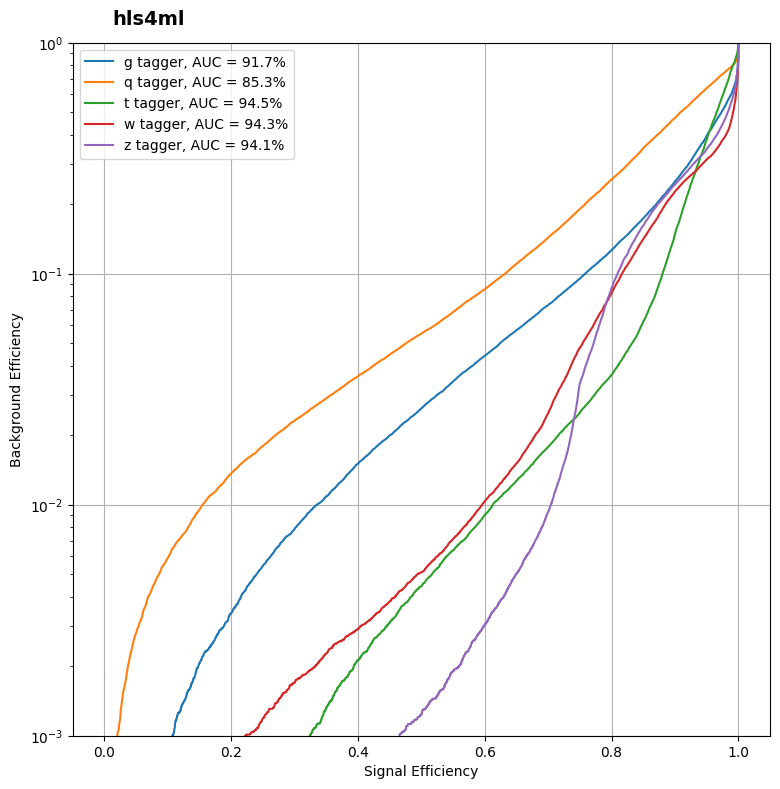

In [18]:
import plotting
from sklearn.metrics import accuracy_score

y_hgq = model.predict(X_test)
print("Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hgq, axis=1))))
plt.figure(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_hgq, classes)


In [19]:
from hgq.utils import trace_minmax
import hls4ml

# Trace the required number of integer bits for activations
# This step is only necessary when using WRAP overflow mode (recommended) for data.
trace_minmax(model, X_test, verbose=True)

config = hls4ml.utils.config_from_keras_model(model, granularity='name', backend='Vitis')

config['Model']['ReuseFactor'] = 1
config['Model']['Strategy'] = 'Distributed Arithmetic'
#config['LayerName']['dense_1']['Strategy'] = 'Resource'

print("-----------------------------------")
print("Configuration")
plotting.print_dict(config)
print("-----------------------------------")
hls_model = hls4ml.converters.convert_from_keras_model(
    model, hls_config=config, backend='Vitis', output_dir='model_HGQ/hls4ml_prj', part='xcu250-figd2104-2L-e'
)

hls_model.compile()
X_test = np.ascontiguousarray(X_test)
y_hls = hls_model.predict(X_test)



dense_0: 7400
dense_1: 6451
dense_2: 3347
dense_3: 1669
Total: 18867
-----------------------------------
Configuration
Model
  Precision
    default:         fixed<16,6>
  ReuseFactor:       1
  Strategy:          Distributed Arithmetic
  BramFactor:        1000000000
  TraceOutput:       False
LayerName
  input_layer
    Trace:           False
    Precision
      result:        auto
  dense_0_iq
    Trace:           False
    Precision
      result:        auto
  dense_0
    Trace:           False
    Precision
      result:        auto
      weight:        auto
      bias:          auto
      accum:         auto
    ReuseFactor:     1
  dense_0_relu
    Trace:           False
    Precision
      result:        auto
      table:         fixed<18,8,TRN,WRAP,0>
    ReuseFactor:     1
    TableSize:       1024
  dense_1_iq
    Trace:           False
    Precision
      result:        auto
  dense_1
    Trace:           False
    Precision
      result:        auto
      weight:        au

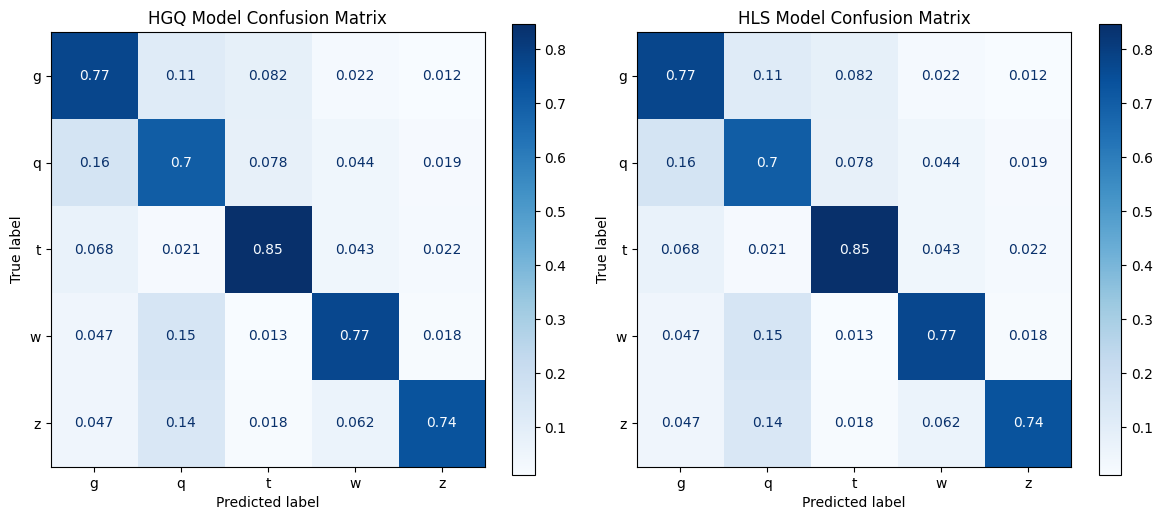

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_hgq_pred = np.argmax(y_hgq, axis=1)
y_hgq_true = np.argmax(y_test, axis=1)
y_hls_pred = np.argmax(y_hls, axis=1)
y_hls_true = np.argmax(y_test, axis=1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
cm_hgq = confusion_matrix(y_hgq_true, y_hgq_pred, normalize='true')
cm_hls = confusion_matrix(y_hls_true, y_hls_pred, normalize='true')

# Plot it
disp_hgq = ConfusionMatrixDisplay(confusion_matrix=cm_hgq, display_labels=classes)
disp_hgq.plot(ax=ax[0],cmap=plt.cm.Blues)
ax[0].set_title('HGQ Model Confusion Matrix')

disp_hls = ConfusionMatrixDisplay(confusion_matrix=cm_hls, display_labels=classes)
disp_hls.plot(ax=ax[1],cmap=plt.cm.Blues)
ax[1].set_title('HLS Model Confusion Matrix')

plt.tight_layout()
plt.show()

In [22]:
# 2. Calculate Mean Squared Error (MSE) between the two
# This tells you how much the "Hardware Math" deviates from "Python Math"
diff = np.mean(np.square(y_hgq - y_hls))
print(f"Quantization Error (MSE): {diff}")

Quantization Error (MSE): 8.666256824171687e-08


In [23]:
from tensorflow.keras.models import load_model
model_baseline = load_model('model_baseline/KERAS_check_best_model.h5')

adam = Adam(learning_rate=0.0001)
model_baseline.compile(optimizer=adam, loss=['categorical_crossentropy'], metrics=['accuracy'])

# 3. Evaluate

score = model_baseline.evaluate(dataset_test)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

y_baseline = model_baseline.predict(np.ascontiguousarray(X_test))

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7362 - loss: 0.8109
Test loss: 0.8108834028244019
Test accuracy: 0.7362470030784607
5188/5188 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


In [24]:
print(y_hls[:5])
print(y_hgq[:5])

[[ 1.75390625  0.82226562 -2.22265625 -0.40429688 -0.53320312]
 [-0.328125    1.86132812 -3.16210938 -0.10742188 -0.20019531]
 [ 0.88671875  0.64160156  2.82421875 -4.19140625 -4.65234375]
 [-0.41210938 -0.49121094  6.37890625 -3.74023438 -3.72167969]
 [ 0.5234375   0.02148438  5.1171875  -4.48242188 -4.29882812]]
[[ 1.7539062   0.8222656  -2.2226562  -0.40429688 -0.5332031 ]
 [-0.328125    1.8613281  -3.1621094  -0.10742188 -0.20019531]
 [ 0.88671875  0.64160156  2.8242188  -4.1914062  -4.6523438 ]
 [-0.41210938 -0.49121094  6.3789062  -3.7402344  -3.7216797 ]
 [ 0.5234375   0.02148438  5.1171875  -4.482422   -4.298828  ]]


Max Bit-Error: 0.115234
HGQ2  Accuracy: 0.7655240963855422
hls4ml Accuracy: 0.7655240963855422
Keras Accuracy: 0.7362469879518072


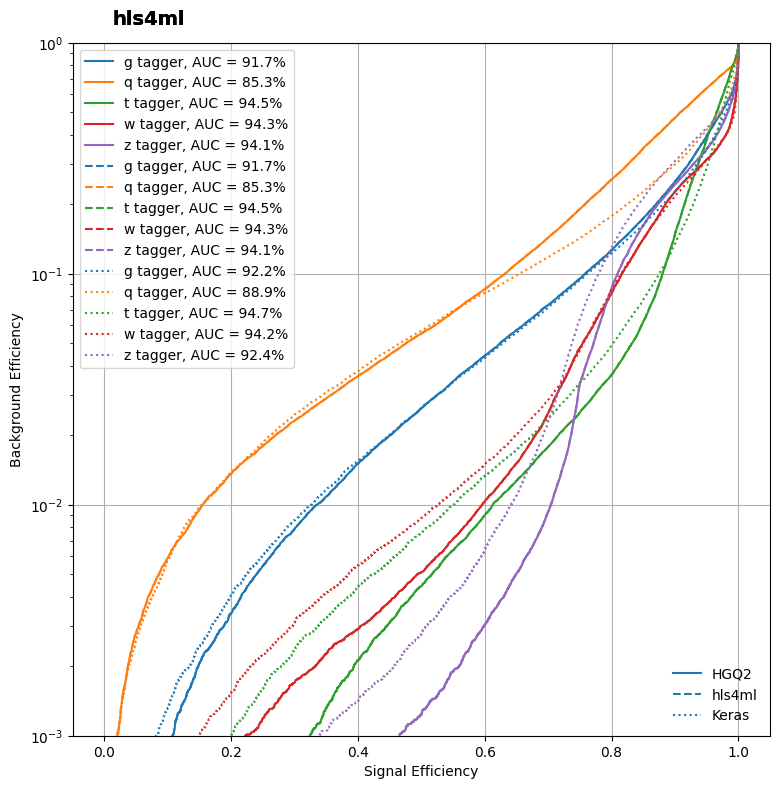

In [25]:

# check bit-accuracy by comparing the outputs of HGQ and hls4ml
max_diff = np.max(np.abs(y_hgq - y_hls))
print("Max Bit-Error: {:.6f}".format(max_diff))

print("HGQ2  Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hgq, axis=1))))
print("hls4ml Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls, axis=1))))
print("Keras Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_baseline, axis=1))))

fig, ax = plt.subplots(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_hgq, classes)
plt.gca().set_prop_cycle(None)  # reset the colors
_ = plotting.makeRoc(y_test, y_hls, classes, linestyle='--')
plt.gca().set_prop_cycle(None)
_ = plotting.makeRoc(y_test, y_baseline, classes, linestyle=':')

from matplotlib.lines import Line2D

lines = [Line2D([0], [0], ls='-'), 
         Line2D([0], [0], ls='--'),
         Line2D([0], [0], ls=':')]

from matplotlib.legend import Legend

leg = Legend(ax, lines, labels=['HGQ2', 'hls4ml', 'Keras'], loc='lower right', frameon=False)
ax.add_artist(leg)

In [36]:
import gc
import keras.backend as K
import tensorflow as tf

# 1. Clear Keras global state
K.clear_session()

# 2. Force garbage collection to reclaim memory from deleted objects
gc.collect()

# 3. (Optional) If using GPU, reset the memory
# Note: This is only available in some versions/backends
if tf.config.list_physical_devices('GPU'):
    try:
        from numba import cuda
        cuda.select_device(0)
        cuda.close()
    except:
        pass